In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv
/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv")
test_df = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(1296675, 23) (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
train_df.info()
train_df["is_fraud"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [5]:
cols_to_drop = ["Unnamed: 0", "trans_date_trans_time", "cc_num", "merchant", 
                 "first", "last", "street", "city", "state", "zip", "lat", "long", 
                 "job", "dob", "trans_num", "unix_time", "merch_lat", "merch_long"]

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

train_df.head()

,category,amt,gender,city_pop,is_fraud
0,misc_net,4.97,F,3495,0
1,grocery_pos,107.23,F,149,0
2,entertainment,220.11,M,4154,0
3,gas_transport,45.00,M,1939,0
4,misc_pos,41.96,M,99,0


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["gender"] = le.fit_transform(train_df["gender"])
test_df["gender"] = le.transform(test_df["gender"])

le2 = LabelEncoder()
train_df["category"] = le2.fit_transform(train_df["category"])
test_df["category"] = le2.transform(test_df["category"])

train_df.head()

,category,amt,gender,city_pop,is_fraud
0,8,4.97,0,3495,0
1,4,107.23,0,149,0
2,0,220.11,1,4154,0
3,2,45.00,1,1939,0
4,9,41.96,1,99,0


In [7]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

In [8]:
scaler = StandardScaler()
X_train["amt"] = scaler.fit_transform(X_train[["amt"]])
X_test["amt"] = scaler.transform(X_test[["amt"]])

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

In [11]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred1 = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.995668674276028
[[553312    262]
 [  2145      0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



In [12]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred2 = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Decision Tree Accuracy: 0.9964316498086263
[[552465   1109]
 [   874   1271]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.53      0.59      0.56      2145

    accuracy                           1.00    555719
   macro avg       0.77      0.80      0.78    555719
weighted avg       1.00      1.00      1.00    555719



In [15]:
rf = RandomForestClassifier(
    n_estimators=10,  
    max_depth=10,      
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred3 = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

Random Forest Accuracy: 0.9689393380467467
[[536448  17126]
 [   135   2010]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.11      0.94      0.19      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.95      0.59    555719
weighted avg       1.00      0.97      0.98    555719



In [16]:
print("Logistic Regression:", accuracy_score(y_test, y_pred1))
print("Decision Tree:", accuracy_score(y_test, y_pred2))
print("Random Forest:", accuracy_score(y_test, y_pred3))

Logistic Regression: 0.995668674276028
Decision Tree: 0.9964316498086263
Random Forest: 0.9689393380467467


In [17]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred1 = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Logistic Regression Accuracy: 0.9487924652567215
[[525647  27927]
 [   530   1615]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    553574
           1       0.05      0.75      0.10      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.85      0.54    555719
weighted avg       1.00      0.95      0.97    555719



In [18]:
print("Model Comparison")
print("-" * 40)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred3))

Model Comparison
----------------------------------------
Logistic Regression Accuracy: 0.9487924652567215
Decision Tree Accuracy: 0.9964316498086263
Random Forest Accuracy: 0.9689393380467467


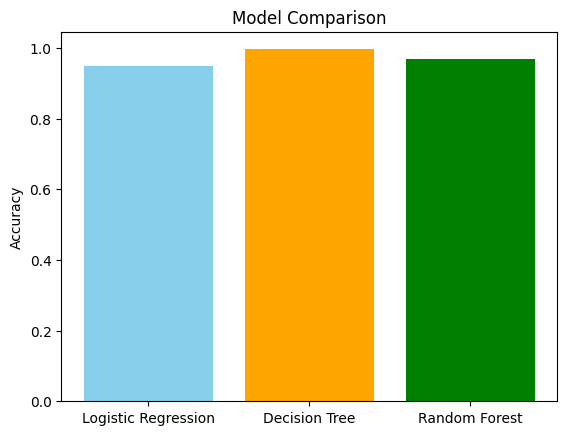

In [19]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [accuracy_score(y_test, y_pred1), accuracy_score(y_test, y_pred2), accuracy_score(y_test, y_pred3)]

plt.bar(models, accuracies, color=["skyblue", "orange", "green"])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()